# Lecture 04: Density Histograms, Functions, Group and Pivot, and Join

---

## Overview

* [Distributions](#Distributions)
* [Distributions of Categorical Variables](#Distributions-of-Categorical-Variables)
* [Distributions of Numerical Variables](#Distributions-of-Numerical-Variables)
* [Area Principle](#Area-Principle)
* [Creating Density Histograms](#Creating-Density-Histograms)
* [Density and Area](#Density-and-Area)

---

## Set Up the Notebook

In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

---

## Distributions

---

### Terminology

* Individuals: those whose features are recorded
* Variable: a feature, an attribute
* A variable has different values
* Values can be numerical or categorical, and of many subtypes within these 
* Each individual has exactly one value of the variable
* Distribution: For each different value of the variable, the frequency of individuals that have that value

---

## Distributions of Categorical Variables

---

### Categorical Distribution

Here we will load a data set with the highest-1000 grossing movies as of 2024, according to IMDB.

In [3]:
top_movies = Table.read_table('top_grossing_movies.csv')
top_movies.show(3)

Created,Modified,Title,URL,Title Type,IMDb Rating,Runtime (mins),Year,Genres,Num Votes,Release Date,Directors,Gross,Gross (Adjusted)
2023-01-06,2023-01-06,Gone with the Wind,https://www.imdb.com/title/tt0031381/,movie,8.2,238,1939,"Drama, Romance, War",318271,1939-12-15,"Sam Wood, George Cukor, Victor Fleming",402382193,7.84414e+09
2023-01-06,2023-01-06,Bambi,https://www.imdb.com/title/tt0034492/,movie,7.3,69,1942,"Animation, Adventure, Drama, Family",145676,1942-08-09,"Samuel Armstrong, Paul Satterfield, Graham Heid, James A ...",267447150,4.44602e+09
2023-01-06,2023-01-06,Titanic,https://www.imdb.com/title/tt0120338/,movie,7.9,194,1997,"Drama, Romance",1187108,1997-11-01,James Cameron,2201647264,3.71701e+09


---

The following code:
* Creates a column called `'Decade'` showing the decade that the move was originally released in. 
* Reduces the table to just the columns `'Title'`, `'Year'`, `'Decade'`, `'Gross'`, and `'Gross (Adjusted)'`.
* Relabels `'Year'` as `'Release Year'`.

_This code uses NumPy's `astype` array method. This function converts all the data in an array to a specific data type. You will not be responsible for using this function in this course._

In [4]:
decades = (np.floor(top_movies.column('Year') / 10) * 10).astype(int)
top_movies = top_movies.with_column('Decade', decades)
top_movies = top_movies.select('Title', 'Year', 'Decade', 'Gross', 'Gross (Adjusted)')
top_movies = top_movies.relabeled('Year', 'Release Year')
top_movies

Title,Release Year,Decade,Gross,Gross (Adjusted)
Gone with the Wind,1939,1930,402382193,7.84414e+09
Bambi,1942,1940,267447150,4.44602e+09
Titanic,1997,1990,2201647264,3.71701e+09
Avatar,2009,2000,2922917914,3.69178e+09
Snow White and the Seven Dwarfs,1937,1930,184925486,3.47981e+09
Star Wars,1977,1970,775398007,3.46716e+09
Avengers: Endgame,2019,2010,2797501328,2.96506e+09
The Exorcist,1973,1970,441306145,2.69326e+09
Jaws,1975,1970,476512065,2.40001e+09
Star Wars: Episode VII - The Force Awakens,2015,2010,2069521700,2.36598e+09


---

The decade values can be thought of as a categorical attribute for the movie. Use the `group` table method to show the distribution of decades. We will cover `group` more in detail in a future lecture.

In [5]:
decade_distribution = top_movies.group('Decade').sort('count', descending=True)
decade_distribution

Decade,count
2010,457
2000,286
1990,151
2020,60
1980,31
1970,10
1930,2
1960,2
1940,1


In [6]:
sum(decade_distribution.column('count'))

1000

---

Visualize the distribution of decades.

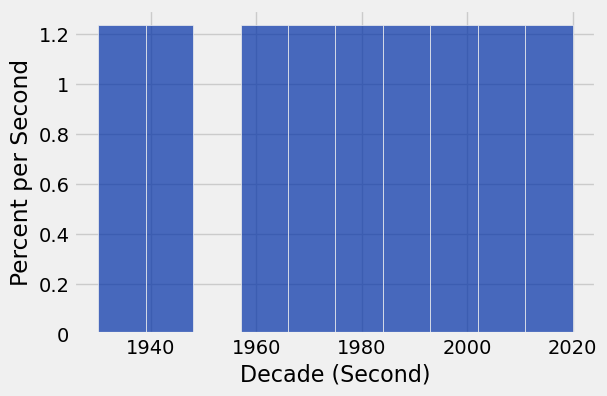

In [7]:
decade_distribution.hist('Decade', unit='Second')

---

## Distributions of Numerical Variables

---

### Binning Numerical Values

Binning is counting the number of numerical values that lie within ranges, called bins.
* Bins are defined by their lower bounds (inclusive)
* The upper bound is the lower bound of the next bin

For example, the values 188, 170, 189, 163, 183, 171, 185, 168, 173, ... could be binned as follows:

<img src="./binning_example.png" alt="A binning of the example data" width = 80%>

---

### Binning

In [8]:
top_movies

Title,Release Year,Decade,Gross,Gross (Adjusted)
Gone with the Wind,1939,1930,402382193,7.84414e+09
Bambi,1942,1940,267447150,4.44602e+09
Titanic,1997,1990,2201647264,3.71701e+09
Avatar,2009,2000,2922917914,3.69178e+09
Snow White and the Seven Dwarfs,1937,1930,184925486,3.47981e+09
Star Wars,1977,1970,775398007,3.46716e+09
Avengers: Endgame,2019,2010,2797501328,2.96506e+09
The Exorcist,1973,1970,441306145,2.69326e+09
Jaws,1975,1970,476512065,2.40001e+09
Star Wars: Episode VII - The Force Awakens,2015,2010,2069521700,2.36598e+09


In [9]:
min_year = min(top_movies.column('Release Year'))
max_year = max(top_movies.column('Release Year'))
(min_year, max_year)

(1937, 2022)

---

Bin the release year data based on bins with unequal widths. We are using the `bin` table method to do this, but you will **not** typically work with the `bin` table method in our assignments/exams.

In [10]:
unequally_spaced_bins = make_array(1937, 2000, 2010, 2020, 2022)

In [11]:
top_movies.bin('Release Year', bins=unequally_spaced_bins)

bin,Release Year count
1937,197
2000,286
2010,457
2020,60
2022,0


The bin values represent the left-endpoint of the bin, except the last row bin value represents the right endpoint of the preceding bin.

---

Bin the release year data based on bins with equal width.

In [12]:
binned_by_decade = top_movies.bin('Release Year', bins=np.arange(1930, 2031, 10))
binned_by_decade.show()

bin,Release Year count
1930,2
1940,1
1950,0
1960,2
1970,10
1980,31
1990,151
2000,286
2010,457
2020,60


---

## Area Principle

---

### Area Principle

Areas should be proportional to the values they represent.

* For example, if you represent 20% with ■, then 40% should be represented with twice that area ■■.
* The following visualization from [Gizmodo in 2012](https://gizmodo.com/holy-f-ck-the-new-ipad-has-a-gigantic-70-percent-large-5893738) accompanied the statement that the new iPad battery was "A gigantic 70-percent larger!" Does the visualization satisfy the area principle?

<img src="./ipad_battery_comparison.jpeg" alt="A comparison of iPad batteries that violates the Area Principle" width = 50%>

---

## Creating Density Histograms

---

### Density Histograms

* Chart that displays the distribution of a numerical variable
* Uses bins; there is one bar corresponding to each bin
* Uses the area principle: The area of each bar is the percent of individuals in the corresponding bin


---

### Density Histograms

Create a density histogram of the release years using the default bins.

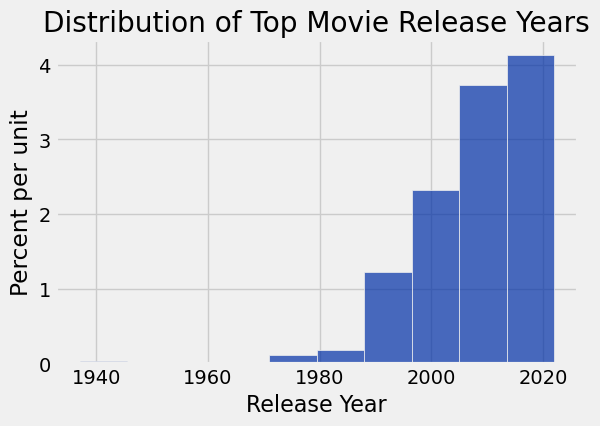

In [13]:
top_movies.hist('Release Year')

# Formatting that you are not responsible for
plt.title('Distribution of Top Movie Release Years')
plt.show()

---

Now, use the unequally spaced bins.

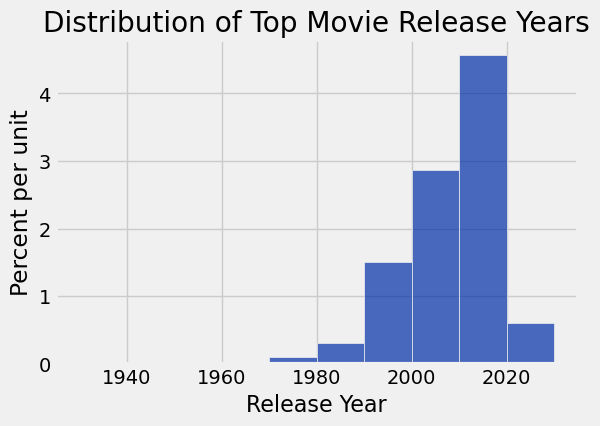

In [14]:
top_movies.hist('Release Year',bins=np.arange(1930, 2031, 10))

# Formatting you are not responsible for
plt.title('Distribution of Top Movie Release Years')
plt.show()

---

Try using bins based on decades instead.

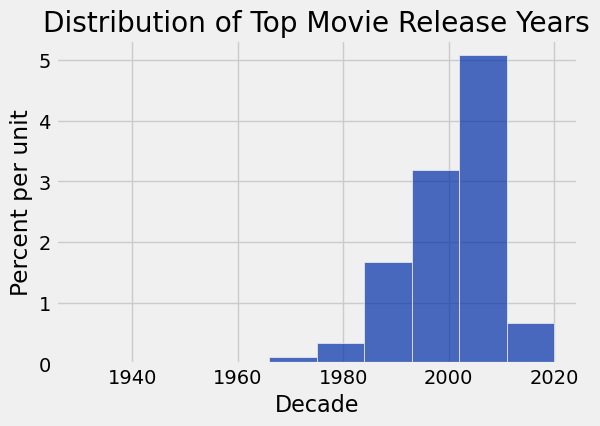

In [15]:
top_movies.hist('Decade')


# Formatting you are not responsible for
plt.title('Distribution of Top Movie Release Years')
plt.show()

---

## Density and Area

---

### Histogram Axes

* By default, `hist` uses a scale (`normed=True`) that ensures the area of the chart sums to 100%
* The area of each bar is a percentage of the whole
* The horizontal axis is a number line (e.g., years), and the bins sizes don't have to be equal to each other
* The vertical axis is a rate (e.g., percent per year)

---

---

### Height Measures Density

* The height measures the percent of data in the bin relative to the amount of space in the bin.
* The general formula for height is: $$\text{height } = \frac{\text{percent in bin}}{\text{width of bin}}$$
* Height measures crowdedness, or density.
* Units: percent per unit on the horizontal axis



---

### How to Calculate Height

The $[1990, 2000)$ bin contains $151$ out of $1,000$ movies
* $151$ out of $1000$ is $15.1\%$
* The bin is $2000 - 1990 = 10$ years wide
* The height of the bar is calculated to be: $$\frac{15.1 \text{ percent}}{10 \text{ years}} = 1.51 \text{ percent per year}$$


---

### Area Measures Percent

* The area of a bar is the percent in the bin.
* The area of a bar can be calculated by the formula: $\text{area of a bar } = \text{ height of the bar} \times \text{ width of bin}$.


---

### How to Calculate Area

A bin that is $10$ years wide and has a density of $1.51$ percent per year contains $10 * 1.51 = 15.1$ percent of the data.

---

### Area or Height

In general:
* Use area when addressing a question like "How many individuals in the bin?"
* Use height when addressing a question like "How crowded is the bin?"

---

### Bar Chart or Histogram?

* Use a bar chart to visualize when the:
    * Distribution of categorical variable
    * Bars have arbitrary (but equal) widths and spacings 
    * Height (or length) and area of bars proportional to the percent of individuals
* Use a histogram to visualize when the:
    * Distribution of numerical variable
    * Horizontal axis is numerical: to scale, no gaps, bins can be unequal
    * Area of bars proportional to the percent of individuals; height measures density

---

# Functions

---

## Overview

* [Defining Functions](#Defining-Functions)
* [Apply](#Apply)

---

## Defining Functions

---

### `def` Statements

User-defined functions give names to blocks of code.


``` python
def spread(values):
    """Return the spread of the values.

    Keyword argument:
    values: an array-like object of numerical values
    """
    value_spread = max(values) - min(values)
    return value_spread
```

---

### The First Line


``` python
def spread(values):

```

* `def` is a Python keyword that indicates you are defining a function
* `spread` is the name of the function. This is how the function can be referenced.
* `values` is the function argument. 
    * _A function may have 0, 1, 2, ... arguments._
    * `values` serves as a placeholder in the definition for whatever input you actually provide.
    * You can set the default value for an argument with an assignment statement.
* The `:` is required.

---

### The Docstring

``` python
    """Return the spread of the values.

    Keyword argument:
    values: an array-like object of numerical values
    """
```

* The docstring provides documentation on what the function does.
* Everything between the triple double quotes is included in the docstring.

---

### The Body


``` python
    value_spread = max(values) - min(values)
    return value_spread
    
```

* `value_spread = ...` and `return value_spread` are part of the body of the function. 
    * This is the code that you have named as `spread`.
    * The spacing is important for identifying the body.
* `return value_spread` is the return statement for the function. _A function does not need to have a return statement._

---

In [ ]:
def spread(values):
    """Return the spread of the values.

    Keyword argument:
    values: an array-like object of numerical values
    """
    value_spread = max(values) - min(values)
    return value_spread

---

In [ ]:
spread?

---

### Demo: Functions

Create a simple function with one argument and demonstrate using it.

In [20]:
def percents(counts):
    """Convert the values in array_x to percents out of the total of array_x."""
    total = counts.sum()
    return np.round((counts/total)*100, 2)

In [21]:
some_array = make_array(7, 10, 4)
percents(some_array)

array([ 33.33,  47.62,  19.05])

In [ ]:
def biggest_difference(array_x):
    """Find the biggest difference in absolute value between two adjacent elements of array_x."""
    diffs = np.diff(array_x)
    absolute_diffs = abs(diffs)
    return max(absolute_diffs)

some_numbers = make_array(2, 4, 5, 6, 4, -1, 1)
big_diff = biggest_difference(some_numbers)
print("The biggest difference is", big_diff)

In [ ]:
def percents(counts, decimal_places):
    """Convert the values in array_x to percents out of the total of array_x."""
    total = counts.sum()
    return np.round((counts/total)*100, decimal_places)

parts = make_array(2, 1, 4)
print("Rounded to 1 decimal place: ", percents(parts, 1))
print("Rounded to 2 decimal places:", percents(parts, 2))
print("Rounded to 3 decimal places:", percents(parts, 3))

In [ ]:
def percents(counts, decimal_places=2):
    """Convert the values in array_x to percents out of the total of array_x."""
    total = counts.sum()
    return np.round((counts/total)*100, decimal_places)

parts = make_array(2, 1, 4)
print("Rounded to 1 decimal place:", percents(parts, 1))
print("Rounded to the default number of decimal places:", percents(parts))

---

### Scope

Notice how the variable and argument names used/declared inside functions do not reach outside of the function.

In [23]:
def myfunc():
  x = 300
  print(x)

myfunc()
x

300


NameError: name 'x' is not defined

In [24]:
def myfunc():
  x = 300
  def myinnerfunc():
    print(x)
  myinnerfunc()

myfunc()

300


In [ ]:
def outer_function():
    msg = "Hello"
    def inner_function():
        print(f"Enclosing scope message: {msg}")
    inner_function()

outer_function()

In [ ]:
y = 20  # Global variable

def another_function():
    print(f"Global variable from inside: {y}")

another_function()

In [ ]:
import numpy as np

# 'total' and the return result are temporary (local) to the function
def percents(counts, decimal_places):
    """Convert counts to percentages, rounded."""
    total = counts.sum() # Local scope
    return np.round((counts/total)*100, decimal_places)

parts = np.array([2, 1, 4])
# Global variables 'parts' and 'p' are accessible here
p = percents(parts, 1) 
print(p) # [28.6 14.3 57.1]
# print(total) # This would create a NameError

---

### Type Agnostic

Show that Python functions are type agnostic.

In [ ]:
def add(a, b):                # Function does not specify type
    return a + b

In [ ]:
print(add(5, 10))             # Output: 15 (integers)
print(add("Hello", "World"))  # Output: HelloWorld (strings)
print(add([1, 2], [3, 4]))    # Output: [1, 2, 3, 4] (lists)

---

### Multiple Arguments

In [ ]:
def percents(counts, decimal_places):
    """Convert the values in array_x to percents out of the total of array_x."""
    total = counts.sum()
    return np.round((counts/total)*100, decimal_places)

In [ ]:
parts = make_array(2, 1, 4)
print("Rounded to 1 decimal place: ", percents(parts, 1))
print("Rounded to 2 decimal places:", percents(parts, 2))
print("Rounded to 3 decimal places:", percents(parts, 3))

In [ ]:
def hypotenuse(x, y):
    hypot_squared = (x ** 2 + y ** 2)
    hypot = hypot_squared ** 0.5
    return hypot

In [ ]:
hypotenuse(1, 2)

In [ ]:
hypotenuse(3, 4)

In [7]:
def age(year):
    age = 2026 - year
    return age

In [5]:
def name_and_age(name, year):
    return name + ' is ' + str(age(year)) + ' years old.'

In [8]:
name_and_age('John', 1980)

'John is 46 years old.'

---

### No Arguments

Create and use a function that has no arguments.

In [ ]:
def greet():
    print("Hello, world!")

In [ ]:
greet()  # Output: Hello, world!

---

### Apply

* The apply method creates an array by calling a function on every element in input column(s)
    * First argument: The function to apply
    * Other arguments: The input column(s)
* Produces an array containing the output of the function on each input column element.
* Example application: `table_name.apply(function_name, 'column_label')`


---

### Apply

Show how to apply a function to a table.

In [28]:
def cut_off_at_100(x):
    """The smaller of x and 100"""
    return min(x, 100)

In [30]:
ages = Table().with_columns(
    'Person', make_array('A', 'B', 'C', 'D', 'E', 'F'),
    'Age', make_array(17, 117, 52, 100, 6, 101)
)
ages

Person,Age
A,17
B,117
C,52
D,100
E,6
F,101


In [ ]:
ages.apply(cut_off_at_100, 'Age')

In [ ]:
ages.with_column(
    'Cut Off Age', ages.apply(cut_off_at_100, 'Age')
)

In [ ]:
cut_off = cut_off_at_100

In [12]:
ages = Table().with_columns(
    'Person', make_array('Jim', 'Pam', 'Michael', 'Creed'),
    'Birth Year', make_array(1985, 1988, 1967, 1904)
)
ages

Person,Birth Year
Jim,1985
Pam,1988
Michael,1967
Creed,1904


In [13]:
ages.apply(age, 'Birth Year')

array([ 41,  38,  59, 122])

In [14]:
make_array(age(ages.column('Birth Year').item(0)),
           age(ages.column('Birth Year').item(1)),
           age(ages.column('Birth Year').item(2)),
           age(ages.column('Birth Year').item(3)))

array([ 41,  38,  59, 122])

In [15]:
ages.apply(name_and_age, 'Person', 'Birth Year')

array(['Jim is 41 years old.', 'Pam is 38 years old.',
       'Michael is 59 years old.', 'Creed is 122 years old.'],
      dtype='<U24')

---

## Example: Prediction
The table below is adapted from a historical data set on the heights of parents and their adult children. Each row corresponds to one adult child. The variables are a numerical code for the family, the heights (in inches) of the father and mother, the number of children in the family, as well as the child’s birth rank (1 = oldest), sex (coded only as “male” or “female”), and height in inches.

In [33]:
# Data on heights of parents and their adult children
family_heights = Table.read_table('family_heights.csv').drop(3)
family_heights

family,father,mother,children,order,sex
1,78.5,67,4,1,male
1,78.5,67,4,2,female
1,78.5,67,4,3,female
1,78.5,67,4,4,female
2,75.5,66.5,4,1,male
2,75.5,66.5,4,2,male
2,75.5,66.5,4,3,female
2,75.5,66.5,4,4,female
3,75,64,2,1,male
3,75,64,2,2,female


In [ ]:
parent_averages = (family_heights.column('father') + family_heights.column('mother'))/2
heights = Table().with_columns(
    'Parent Average', parent_averages,
    'Child', family_heights.column('childHeight')
)
heights

In [ ]:
heights.scatter('Parent Average')

In [ ]:
heights.scatter('Parent Average')
plots.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plots.plot([68.5, 68.5], [50, 85], color='red', lw=2)
plots.scatter(68, 67.62, color='gold', s=40);

In [ ]:
def predict_child(p_avg):
    """Predict the height of a child whose parents have a parent average height of p_avg.
    
    The prediction is the average height of the children whose parent average height is
    in the range p_avg plus or minus 0.5.
    """
    
    close_points = heights.where('Parent Average', are.between(p_avg-0.5, p_avg + 0.5))
    return np.average(close_points.column('Child'))                     

In [ ]:
# Apply predict_child to all the midparent heights

heights_with_predictions = heights.with_column(
    'Prediction', heights.apply(predict_child, 'Parent Average')
)

In [ ]:
heights_with_predictions

In [ ]:
heights_with_predictions.scatter('Parent Average')

---

# Group and Pivot

---

## Overview

* [Grouping](#Grouping)
* [Pivot Tables](#Pivot-Tables)
* [Cross-Classification](#Cross-Classification)

---

## Grouping Data

<a href="https://epirhandbook.com/images/Grouping_1500x500.png"><img src="./grouping_R.png" width=400px alt="3 clusters of objects grouped in different ways based on shape and color."><a/>

* **Identify Patterns and Trends**
    * Grouping helps reveal insights by summarizing data across categories, making it easier to spot trends.
* **Simplify Large Datasets**
    * Instead of analyzing raw data row by row, grouping organizes information into meaningful summaries.
* **Compare Categories**
    * Easily compare different groups, such as average income by city or total sales by product type.
* **Prepare Data for Visualization**
    * Grouping is a key step in creating charts and tables that highlight important relationships in data.

---

### Grouping by One Column

The group method aggregates all rows with the same value for a column into a single row in the resulting table.
* First argument: Which column to group by
* Second argument: (Optional) How to combine values
    * `len` — number of grouped values (default)
    * `list` — list of all grouped values
    * `sum`  — total of all grouped values
    * ...


---

### Demo: Grouping by One Column

In [36]:
cones = Table().with_columns(
    'Flavor', make_array('strawberry', 'chocolate', 'chocolate', 'strawberry', 'chocolate'),
    'Price', make_array(3.55, 4.75, 6.55, 5.25, 5.25)
)
cones

Flavor,Price
strawberry,3.55
chocolate,4.75
chocolate,6.55
strawberry,5.25
chocolate,5.25


In [37]:
cones.group('Flavor')

Flavor,count
chocolate,3
strawberry,2


In [ ]:
cones.group('Flavor', sum)

In [ ]:
cones.where('Flavor', are.equal_to('chocolate')).column('Price')

In [38]:
sum(cones.where('Flavor', are.equal_to('chocolate')).column('Price'))

16.550000000000001

In [ ]:
# For each distinct value in `Flavor, access all the rows
# and create an array of `Price`

cones_choc = cones.where('Flavor', are.equal_to('chocolate')).column('Price')
cones_strawb = cones.where('Flavor', are.equal_to('strawberry')).column('Price')

# Display the arrays in a table

grouped_cones = Table().with_columns(
    'Flavor', make_array('chocolate', 'strawberry'),
    'Array of All the Prices', make_array(cones_choc, cones_strawb)
)

# Append a column with the sum of the `Price` values in each array

price_totals = grouped_cones.with_column(
    'Sum of the Array', make_array(sum(cones_choc), sum(cones_strawb))
)
price_totals

In [ ]:
cones.group('Flavor', max)

In [ ]:
price_maxes = grouped_cones.with_column(
    'Max of the Array', make_array(max(cones_choc), max(cones_strawb))
)
price_maxes

In [ ]:
lengths = grouped_cones.with_column(
    'Length of the Array', make_array(len(cones_choc), len(cones_strawb))
)
lengths

---

### Grouping by Two Columns

The group method can also aggregate all rows that share the combination of values in multiple columns
* First argument: A list of which columns to group by
* Second argument: (Optional) How to combine values

---

### Grouping by Two Columns

In [ ]:
more_cones = Table().with_columns(
    'Flavor', make_array('strawberry', 'chocolate', 'chocolate', 'strawberry', 'chocolate', 'bubblegum'),
    'Color', make_array('pink', 'light brown', 'dark brown', 'pink', 'dark brown', 'pink'),
    'Price', make_array(3.55, 4.75, 5.25, 5.25, 5.25, 4.75)
)

more_cones

In [ ]:
more_cones.group('Flavor')

In [ ]:
more_cones.group(['Flavor', 'Color'])

In [ ]:
more_cones.group(['Flavor', 'Color'], sum)

In [ ]:
more_cones.group(['Flavor', 'Color'])

In [ ]:
more_cones.pivot('Flavor', 'Color')

In [ ]:
more_cones.pivot('Flavor', 'Color', values='Price', collect=sum)

In [ ]:
more_cones.group(['Flavor', 'Color'], sum)

---

### Table Function Visualizer

UC Berkeley's [Table Function Visualizer](https://www.data8.org/interactive_table_functions/) can help us to better understand the `group` table methods, as well as comparing it to what we will learn next, the `pivot` table method .

---

## Pivot Tables

---

### Pivot

* Produces a grid of counts or aggregated values based on two categorical variables
* Two required arguments:
    * First: variable that forms column labels of grid
    * Second: variable that forms row labels of grid
* Two optional arguments (include both or neither)
    * `values=’column_label_to_aggregate’`
    * `collect=function_to_aggregate_with`

---

### Demo: NBA Salaries

In [43]:
nba1 = Table.read_table('nba_salaries.csv')

nba1

rank,name,position,team,salary,season
1,Shaquille O'Neal,C,Los Angeles Lakers,17142000,2000
2,Kevin Garnett,PF,Minnesota Timberwolves,16806000,2000
3,Alonzo Mourning,C,Miami Heat,15004000,2000
4,Juwan Howard,PF,Washington Wizards,15000000,2000
5,Scottie Pippen,SF,Portland Trail Blazers,14795000,2000
6,Karl Malone,PF,Utah Jazz,14000000,2000
7,Larry Johnson,F,New York Knicks,11910000,2000
8,Gary Payton,PG,Seattle SuperSonics,11020000,2000
9,Rasheed Wallace,PF,Portland Trail Blazers,10800000,2000
10,Shawn Kemp,C,Cleveland Cavaliers,10780000,2000


In [45]:
teams_and_money = nba1.select('team', 'salary')
teams_and_money.group('team', sum)

team,salary sum
Atlanta Hawks,1146345077
Bilbao Basket Bilbao Basket,5543116
Boston Celtics,1353465387
Brooklyn Nets,791940722
Charlotte Bobcats,546931673
Charlotte Hornets,726794747
Chicago Bulls,1199006636
Cleveland Cavaliers,1341890490
Dallas Mavericks,1395522485
Denver Nuggets,1277692469


In [47]:
nba1.group('position')

position,count
C,1765
F,578
G,696
GF,1
PF,1731
PG,1475
SF,1454
SG,1699
nan,57


In [48]:
positions_and_money = nba1.select('position', 'salary')
positions_and_money.group('position', np.mean)

position,salary mean
C,5.14486e+06
F,3.52996e+06
G,3.50449e+06
GF,2.17711e+06
PF,4.88913e+06
PG,4.42474e+06
SF,4.45874e+06
SG,4.29807e+06
nan,1.46301e+06


In [49]:
nba1.group('position', np.mean)

position,rank mean,name mean,team mean,salary mean,season mean
C,221.93,,,5.14486e+06,2011
F,267.59,,,3.52996e+06,2012.04
G,285.563,,,3.50449e+06,2012.54
GF,237,,,2.17711e+06,2006
PF,235.983,,,4.88913e+06,2010.99
PG,257.289,,,4.42474e+06,2011.28
SF,253.004,,,4.45874e+06,2011.43
SG,260.055,,,4.29807e+06,2011.88
nan,447.754,,,1.46301e+06,2010.07


---

## Cross-Classification

---

### Group and Pivot Tables

Cross-classification is to put individuals into groups based on the values of 2 or more variables.

For cross-classification:

* Grouped Table
    * Any number of grouping variables
    * One combo of grouping variables per row
    * Aggregate values of all other columns in table
    * Missing combos absent
* Pivot Table
    * Two grouping variables: columns and rows
    * One combo of grouping variables per entry
    * Aggregate values of values column
    * Missing combos = 0 (or empty string)

---

# Join

---

## Overview

* [Joins](#Joins)
* [Bay Wheels](#Bay-Wheels)

---

### Joining Two Tables

To join information in table called `discounts` with a table called `drinks` where the matching values are in the columns `'location'` and `'cafe'`, respectively, use the command:

<img src="./join_command.png" alt="An example join command with labels" width = 70%>

---

The following graph shows how the `drinks` and `discounts` tables are joined.

<img src="./join_example_table.png" alt="Three tables showing how two were joined into one." width = 90%>

---

### Joins

Create the `drinks` and `discounts` tables.

In [50]:
drinks = Table(['Drink', 'Cafe', 'Price']).with_rows([
    ['Milk Tea', 'Asha', 5.5],
    ['Espresso', 'Strada',  1.75],
    ['Latte',    'Strada',  3.25],
    ['Espresso', "FSM",   2]
])
drinks

Drink,Cafe,Price
Milk Tea,Asha,5.5
Espresso,Strada,1.75
Latte,Strada,3.25
Espresso,FSM,2


In [51]:
discounts = Table().with_columns(
    'Coupon % off', make_array(10, 25, 5),
    'Location', make_array('Asha', 'Strada', 'Asha')
)
discounts

Coupon % off,Location
10,Asha
25,Strada
5,Asha


---

Join `discounts` with `drinks` based on the values in `Location` and `Cafe`, respectively.

In [55]:
combined = drinks.join('Cafe', discounts, 'Location')
combined

Cafe,Drink,Price,Coupon % off
Asha,Milk Tea,5.5,10
Asha,Milk Tea,5.5,5
Strada,Espresso,1.75,25
Strada,Latte,3.25,25


---

Add a `'Discounted Price'` column to the table showing the updated drink price after the coupon has been applied.

In [58]:
discounted_frac = 1 - combined.column('Coupon % off') / 100
combined.with_column(
    'Discounted Price', 
    combined.column('Price') * discounted_frac
)

Cafe,Drink,Price,Coupon % off,Discounted Price
Asha,Milk Tea,5.5,10,4.95
Asha,Milk Tea,5.5,5,5.225
Strada,Espresso,1.75,25,1.3125
Strada,Latte,3.25,25,2.4375


---

See what happens when you join tables with the same labels.

In [ ]:
drinks.join('Cafe', drinks, 'Cafe')

---

The Bay Wheels License Agreement outlines that certain system data must be made public. `baywheels.csv` contains all the trips on January 31, 2024, from the [Bay Wheels System Data page](https://www.lyft.com/bikes/bay-wheels/system-data). We've calculated the trip duration (measured in seconds) and included it in the data. Also, we removed any trips that did not have a start or end station name.

---

### Demo: Analyzing Bay Wheels

Load that data into a table called `trips`.

In [19]:
trips = Table.read_table('trip.csv')
trips

Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
913460,765,8/31/2015 23:26,Harry Bridges Plaza (Ferry Building),50,8/31/2015 23:39,San Francisco Caltrain (Townsend at 4th),70,288,Subscriber,2139
913459,1036,8/31/2015 23:11,San Antonio Shopping Center,31,8/31/2015 23:28,Mountain View City Hall,27,35,Subscriber,95032
913455,307,8/31/2015 23:13,Post at Kearny,47,8/31/2015 23:18,2nd at South Park,64,468,Subscriber,94107
913454,409,8/31/2015 23:10,San Jose City Hall,10,8/31/2015 23:17,San Salvador at 1st,8,68,Subscriber,95113
913453,789,8/31/2015 23:09,Embarcadero at Folsom,51,8/31/2015 23:22,Embarcadero at Sansome,60,487,Customer,9069
913452,293,8/31/2015 23:07,Yerba Buena Center of the Arts (3rd @ Howard),68,8/31/2015 23:12,San Francisco Caltrain (Townsend at 4th),70,538,Subscriber,94118
913451,896,8/31/2015 23:07,Embarcadero at Folsom,51,8/31/2015 23:22,Embarcadero at Sansome,60,363,Customer,92562
913450,255,8/31/2015 22:16,Embarcadero at Sansome,60,8/31/2015 22:20,Steuart at Market,74,470,Subscriber,94111
913449,126,8/31/2015 22:12,Beale at Market,56,8/31/2015 22:15,Temporary Transbay Terminal (Howard at Beale),55,439,Subscriber,94130
913448,932,8/31/2015 21:57,Post at Kearny,47,8/31/2015 22:12,South Van Ness at Market,66,472,Subscriber,94702


---

Create a table showing the top 10 longest (duration) rides.

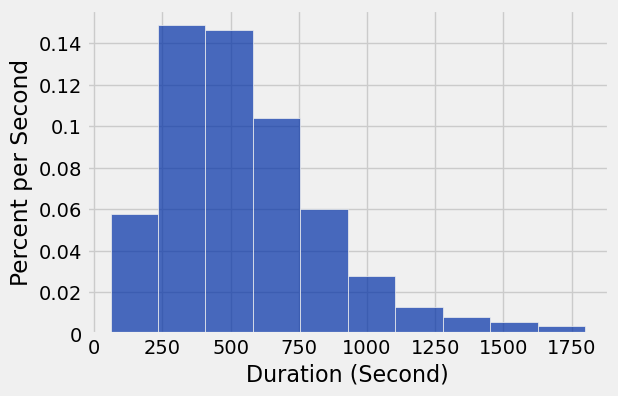

In [20]:
commute = trips.where('Duration', are.below(1800))
commute.hist('Duration', unit='Second')

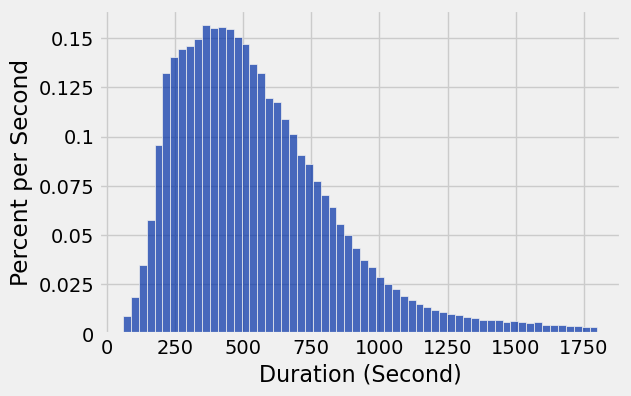

In [21]:
commute.hist('Duration', bins=60, unit='Second')

In [22]:
starts = commute.group('Start Station').sort('count', descending=True)
starts

Start Station,count
San Francisco Caltrain (Townsend at 4th),14352
San Francisco Caltrain 2 (330 Townsend),13307
Harry Bridges Plaza (Ferry Building),9619
Temporary Transbay Terminal (Howard at Beale),8489
Townsend at 7th,8167
Steuart at Market,8109
2nd at Townsend,8013
Embarcadero at Sansome,7968
Market at 10th,6577
Market at Sansome,6265


In [ ]:
commute.group(['Start Station', 'End Station'])

In [ ]:
commute.pivot('Start Station', 'End Station')

In [ ]:
commute.pivot('Start Station', 'End Station', 'Duration', min)

---

There is another data file called `stations.csv` that contains just the latitude and longitude for each station. Join that data with the `starts` table.

In [ ]:
stations = Table.read_table('station.csv')
stations

In [83]:
Marker.map_table(stations.select('lat', 'long', 'name').relabel('name', 'labels'))

---

Use [`Circle`](https://datascience.readthedocs.io/en/master/maps.html#datascience.maps.Circle) to create a map visualization of all the stations with the marker at each station proportional to the number of trips started from that station.

Note that `Circle` requires that the table columns used be labeled and ordered in a certain way.

In [ ]:
sf = stations.where('landmark', are.equal_to('San Francisco'))
sf_map_data = sf.select('lat', 'long', 'name').relabel('name', 'labels')
Circle.map_table(sf_map_data, color='green')

In [ ]:
cities = stations.group('landmark').relabeled('landmark', 'city')
cities

---

In [ ]:
colors = cities.with_column('color', make_array('blue', 'red', 'green', 'orange', 'purple'))
colors

In [ ]:
joined = stations.join('landmark', colors, 'city')
colored = joined.select('lat', 'long', 'name', 'color').relabel('name', 'labels')
Marker.map_table(colored)

In [89]:
starts = commute.group('Start Station').sort('count', descending=True)
starts

Start Station,count
San Francisco Caltrain (Townsend at 4th),14352
San Francisco Caltrain 2 (330 Townsend),13307
Harry Bridges Plaza (Ferry Building),9619
Temporary Transbay Terminal (Howard at Beale),8489
Townsend at 7th,8167
Steuart at Market,8109
2nd at Townsend,8013
Embarcadero at Sansome,7968
Market at 10th,6577
Market at Sansome,6265


---

In [ ]:
station_starts = stations.join('name', starts, 'Start Station')
station_starts

In [ ]:
starts_map_data = station_starts.select('lat', 'long', 'name').with_columns(
    'colors', 'blue',
    'areas', station_starts.column('count') * 0.3
)
starts_map_data.show(3)
Circle.map_table(starts_map_data.relabel('name', 'labels'))

---

## Attribution

This content is licensed under the <a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License (CC BY-NC-SA 4.0)</a> and derived from the <a href="https://www.data8.org/">Data 8: The Foundations of Data Science</a> offered by the University of California, Berkeley.

<img src="./by-nc-sa.png" width=100px>